In [58]:
import numpy as np
import math
import copy

In [15]:
x_train = np.array([[2.10, 5, 1, 45], [1.42, 3, 2, 40], [1.53, 3, 2, 30], [0.85, 2, 1, 36], [1.94, 4, 2, 15], [1.10, 3, 1, 50], [2.35, 4, 2, 8], [1.68, 3, 1, 25]])
y_train = np.array([460, 232, 315, 178, 412, 205, 495, 340])

In [16]:
w = np.array([180.0, 12.0, 8.0, -1.2])
b = 45.0

In [17]:
def predict(x, w, b):
    predict = np.dot(x, w) + b
    return predict

In [18]:
p = predict([1.75, 3, 2, 20], w, b)
print(f"final price: ${p}")

final price: $388.0


In [38]:
def compute_cost(x, y, w, b):
    cost = 0
    m = x.shape[0]
    for i in range(m):
        cost += ((np.dot(x[i], w) + b) - y[i]) ** 2
    cost /= 2 * m
    return cost

In [39]:
cost = compute_cost(x_train, y_train, w, b)
print(f"Cost: {cost}")

Cost: 551.445


In [49]:
def compute_gradient(x, y, w, b):
    m, n = x.shape
    dj_dw = np.zeros(n)
    dj_db = 0

    for i in range(m):
        error = (np.dot(x[i],w) + b) - y[i]
        for j in range(n):
            dj_dw[j] += error * x[i, j]
        dj_db += error

    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

In [50]:
dj_dw, dj_db = compute_gradient(x_train, y_train, w, b)

print(f"dj_dw: {dj_dw}\ndj_db:{dj_db}")

dj_dw: [ 34.283  67.15   41.05  638.125]
dj_db:22.349999999999998


In [74]:
def gradient_descent(x, y, w_init, b_init, alpha, iterations):
    j_history = []

    w = copy.deepcopy(w_init)
    b = b_init
    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w = w - (alpha * dj_dw)
        b = b - (alpha * dj_db)


        j_history.append(compute_cost(x, y, w, b))

        if i % math.ceil(iterations / 100) == 0:
            print(f"iteration: {i}, cost: {j_history[-1]:8.2f}")

    return w, b, j_history

In [81]:
w = np.zeros(x_train.shape[1])
b = 0.
alpha = 2e-5
iterations = 100000

final_w, final_b, cost_history = gradient_descent(x_train, y_train, w, b, alpha, iterations)

print(f"Final value of w {final_w}, and b {final_b:.2f}, final cost = {cost_history[-1]:.2f}")

iteration: 0, cost: 58778.36
iteration: 1000, cost: 18670.96
iteration: 2000, cost: 15606.50
iteration: 3000, cost: 13058.34
iteration: 4000, cost: 10939.44
iteration: 5000, cost:  9177.42
iteration: 6000, cost:  7712.09
iteration: 7000, cost:  6493.45
iteration: 8000, cost:  5479.89
iteration: 9000, cost:  4636.84
iteration: 10000, cost:  3935.55
iteration: 11000, cost:  3352.13
iteration: 12000, cost:  2866.69
iteration: 13000, cost:  2462.73
iteration: 14000, cost:  2126.51
iteration: 15000, cost:  1846.60
iteration: 16000, cost:  1613.53
iteration: 17000, cost:  1419.39
iteration: 18000, cost:  1257.62
iteration: 19000, cost:  1122.77
iteration: 20000, cost:  1010.30
iteration: 21000, cost:   916.45
iteration: 22000, cost:   838.07
iteration: 23000, cost:   772.57
iteration: 24000, cost:   717.76
iteration: 25000, cost:   671.87
iteration: 26000, cost:   633.37
iteration: 27000, cost:   601.04
iteration: 28000, cost:   573.83
iteration: 29000, cost:   550.89
iteration: 30000, cost:

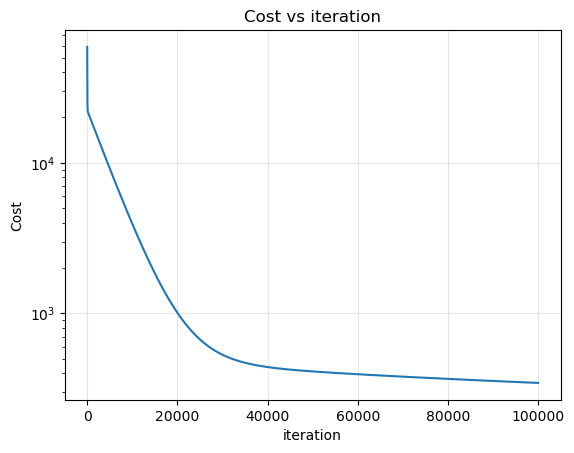

In [82]:
import matplotlib.pyplot as plt

plt.plot(cost_history)
plt.yscale('log')
plt.xlabel("iteration")
plt.ylabel("Cost")
plt.title("Cost vs iteration")
plt.grid(True, alpha=0.3)
plt.show()